# Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("mako")

# Загрузка данных

In [2]:
# df = pd.read_csv('../data/raw/backrooms_survival_v4.csv')
# df = pd.read_csv('../data/raw/backrooms_24h.csv')
df = pd.read_parquet('../data/raw/backrooms_survival_v5.parquet')
df.T

,0,1,2,3,4,5,6,7,8,9,...,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
character_id,1,2,3,4,5,6,7,8,9,10,...,19991,19992,19993,19994,19995,19996,19997,19998,19999,20000
age,37,17,43,31,21,41,16,66,47,18,...,15,28,68,27,33,37,64,14,16,13
sex,male,female,female,female,female,male,female,male,male,male,...,female,male,female,female,female,female,female,male,female,female
height_cm,182,165,169,162,163,179,157,176,174,182,...,167,169,164,177,175,156,157,191,177,170
weight_kg,77,61,63,67,60,86,69,89,77,76,...,65,70,73,65,77,70,50,65,60,69
strength,4,5,6,5,7,9,2,7,2,7,...,4,2,7,4,7,3,5,2,7,5
reaction,2,5,5,6,3,4,9,4,8,9,...,1,2,5,5,7,6,6,2,6,5
stamina,4,6,7,5,4,5,6,4,3,7,...,4,5,7,5,7,7,6,4,4,6
speed,4,3,6,5,4,4,5,6,8,7,...,4,3,4,5,5,8,6,4,4,5
intelligence,8,3,6,4,4,4,7,5,5,3,...,4,5,5,2,7,5,6,5,2,7


# Общая информация

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
character_id,20000.0,10000.500000,5773.647028,1.0000,5000.7500,10000.50000,15000.2500,20000.0
age,20000.0,32.461950,13.045132,12.0000,23.0000,32.00000,41.0000,80.0
height_cm,20000.0,168.856350,9.444500,140.0000,162.0000,169.00000,176.0000,201.0
weight_kg,20000.0,72.774400,12.878094,35.0000,64.0000,73.00000,82.0000,117.0
strength,20000.0,4.972900,1.667544,0.0000,4.0000,5.00000,6.0000,10.0
reaction,20000.0,5.091000,1.644127,0.0000,4.0000,5.00000,6.0000,10.0
stamina,20000.0,5.279500,1.627640,0.0000,4.0000,5.00000,6.0000,10.0
speed,20000.0,5.252300,1.505509,0.0000,4.0000,5.00000,6.0000,10.0
intelligence,20000.0,4.978150,1.833041,0.0000,4.0000,5.00000,6.0000,10.0
perception,20000.0,5.186750,1.682800,0.0000,4.0000,5.00000,6.0000,10.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   character_id                20000 non-null  int64  
 1   age                         20000 non-null  int64  
 2   sex                         20000 non-null  object 
 3   height_cm                   20000 non-null  int64  
 4   weight_kg                   20000 non-null  int64  
 5   strength                    20000 non-null  int64  
 6   reaction                    20000 non-null  int64  
 7   stamina                     20000 non-null  int64  
 8   speed                       20000 non-null  int64  
 9   intelligence                20000 non-null  int64  
 10  perception                  20000 non-null  int64  
 11  agility                     20000 non-null  int64  
 12  endurance                   20000 non-null  int64  
 13  stress_resistance           200

In [5]:
df.isnull().sum().sort_values(ascending=False)

character_id                  0
entity_density                0
has_first_aid_kit             0
medkit_count                  0
has_water                     0
water_amount                  0
has_food                      0
food_amount                   0
has_radio                     0
level_id                      0
level_difficulty              0
visibility                    0
entity_aggression             0
age                           0
resource_density              0
maze_complexity               0
geometry_stability            0
special_rule                  0
spawn_area_danger             0
distance_to_nearest_entity    0
noise_generated               0
time_since_last_encounter     0
survived_24h                  0
survival_time_hours           0
has_backpack                  0
has_knife                     0
flashlight_battery            0
has_flashlight                0
sex                           0
height_cm                     0
weight_kg                     0
strength

# Анализ таргетов

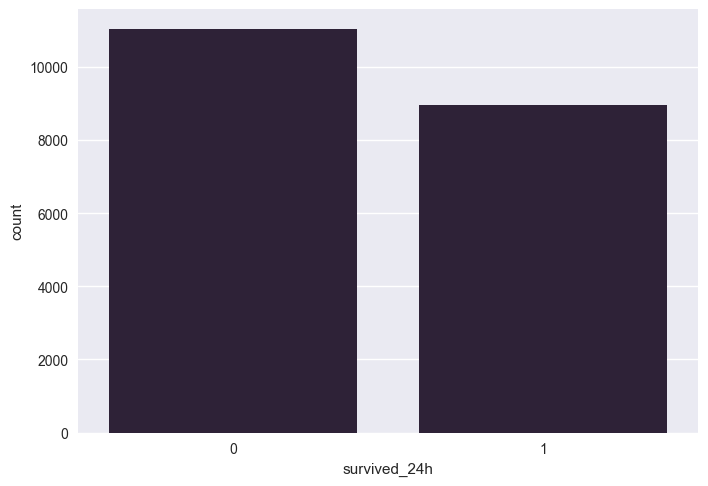

In [6]:
# sns.histplot(df['survived_24h'], kde=True)
sns.countplot(x='survived_24h', data=df)
plt.show()

In [7]:
df['survived_24h'].value_counts(normalize=True)

survived_24h
0    0.55145
1    0.44855
Name: proportion, dtype: float64

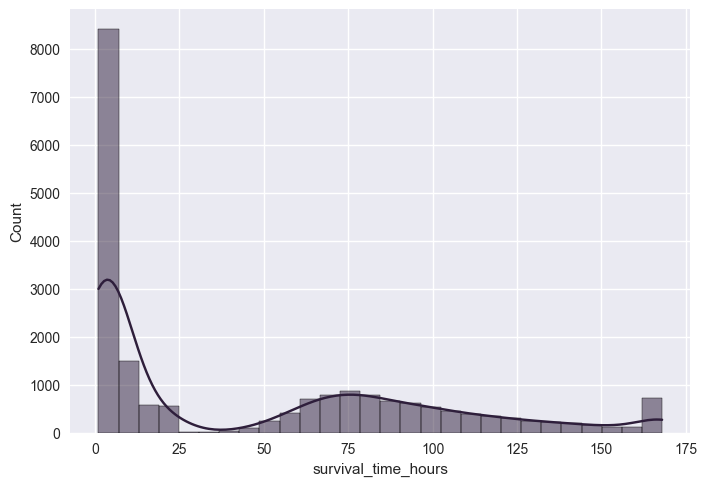

In [8]:
sns.histplot(df['survival_time_hours'], kde=True)
plt.show()

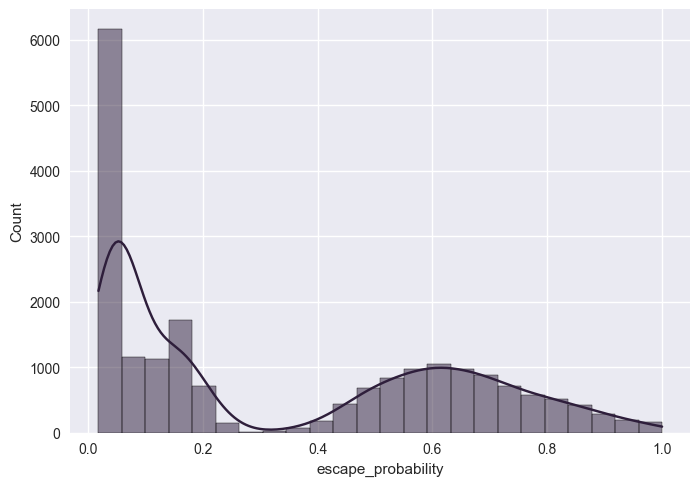

In [9]:
sns.histplot(df['escape_probability'], kde=True)
plt.show()

In [10]:
df.describe()

,character_id,age,height_cm,weight_kg,strength,reaction,stamina,speed,intelligence,perception,...,resource_density,maze_complexity,geometry_stability,spawn_area_danger,distance_to_nearest_entity,noise_generated,time_since_last_encounter,survived_24h,survival_time_hours,escape_probability
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,...,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,32.461950,168.85635,72.774400,4.972900,5.091000,5.27950,5.252300,4.978150,5.18675,...,41.075700,55.736150,43.82140,45.903350,45.257650,25.424850,11.424550,0.448550,46.674800,0.341558
std,5773.647028,13.045132,9.44450,12.878094,1.667544,1.644127,1.62764,1.505509,1.833041,1.68280,...,15.977272,17.604551,16.09866,15.840128,14.517063,10.599126,3.463814,0.497358,51.160265,0.300183
min,1.000000,12.000000,140.00000,35.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.018400
25%,5000.750000,23.000000,162.00000,64.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.00000,...,30.000000,44.000000,33.00000,35.000000,35.000000,18.000000,9.000000,0.000000,3.000000,0.053500
50%,10000.500000,32.000000,169.00000,73.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,...,40.000000,58.000000,43.00000,47.000000,45.000000,25.000000,11.000000,0.000000,13.000000,0.176950
75%,15000.250000,41.000000,176.00000,82.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,...,52.000000,68.000000,54.00000,57.000000,55.000000,33.000000,14.000000,1.000000,85.000000,0.621600
max,20000.000000,80.000000,201.00000,117.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.00000,...,100.000000,100.000000,100.00000,100.000000,100.000000,70.000000,24.000000,1.000000,168.000000,1.000000


In [11]:
df['escape_probability'].kurt()

np.float64(-1.375077047718994)

# Анализ признаков + Выбросы + Пропуски

1. Закодировать категориальные признаки и повторно проанализировать хитмапу

In [12]:
numerical = df.select_dtypes(include=np.number).columns
categorical = df.select_dtypes(include='object').columns
df[categorical].value_counts()

sex     level_id  special_rule    
female  6         darkness            699
male    6         darkness            668
female  7         flooding            569
male    8         cave_isolation      569
female  8         cave_isolation      562
                                     ... 
other   4         trap_exit             1
        7         liminal_office        1
        5         mechanical_noise      1
        6         haunted_hotel         1
        1         cave_isolation        1
Name: count, Length: 255, dtype: int64

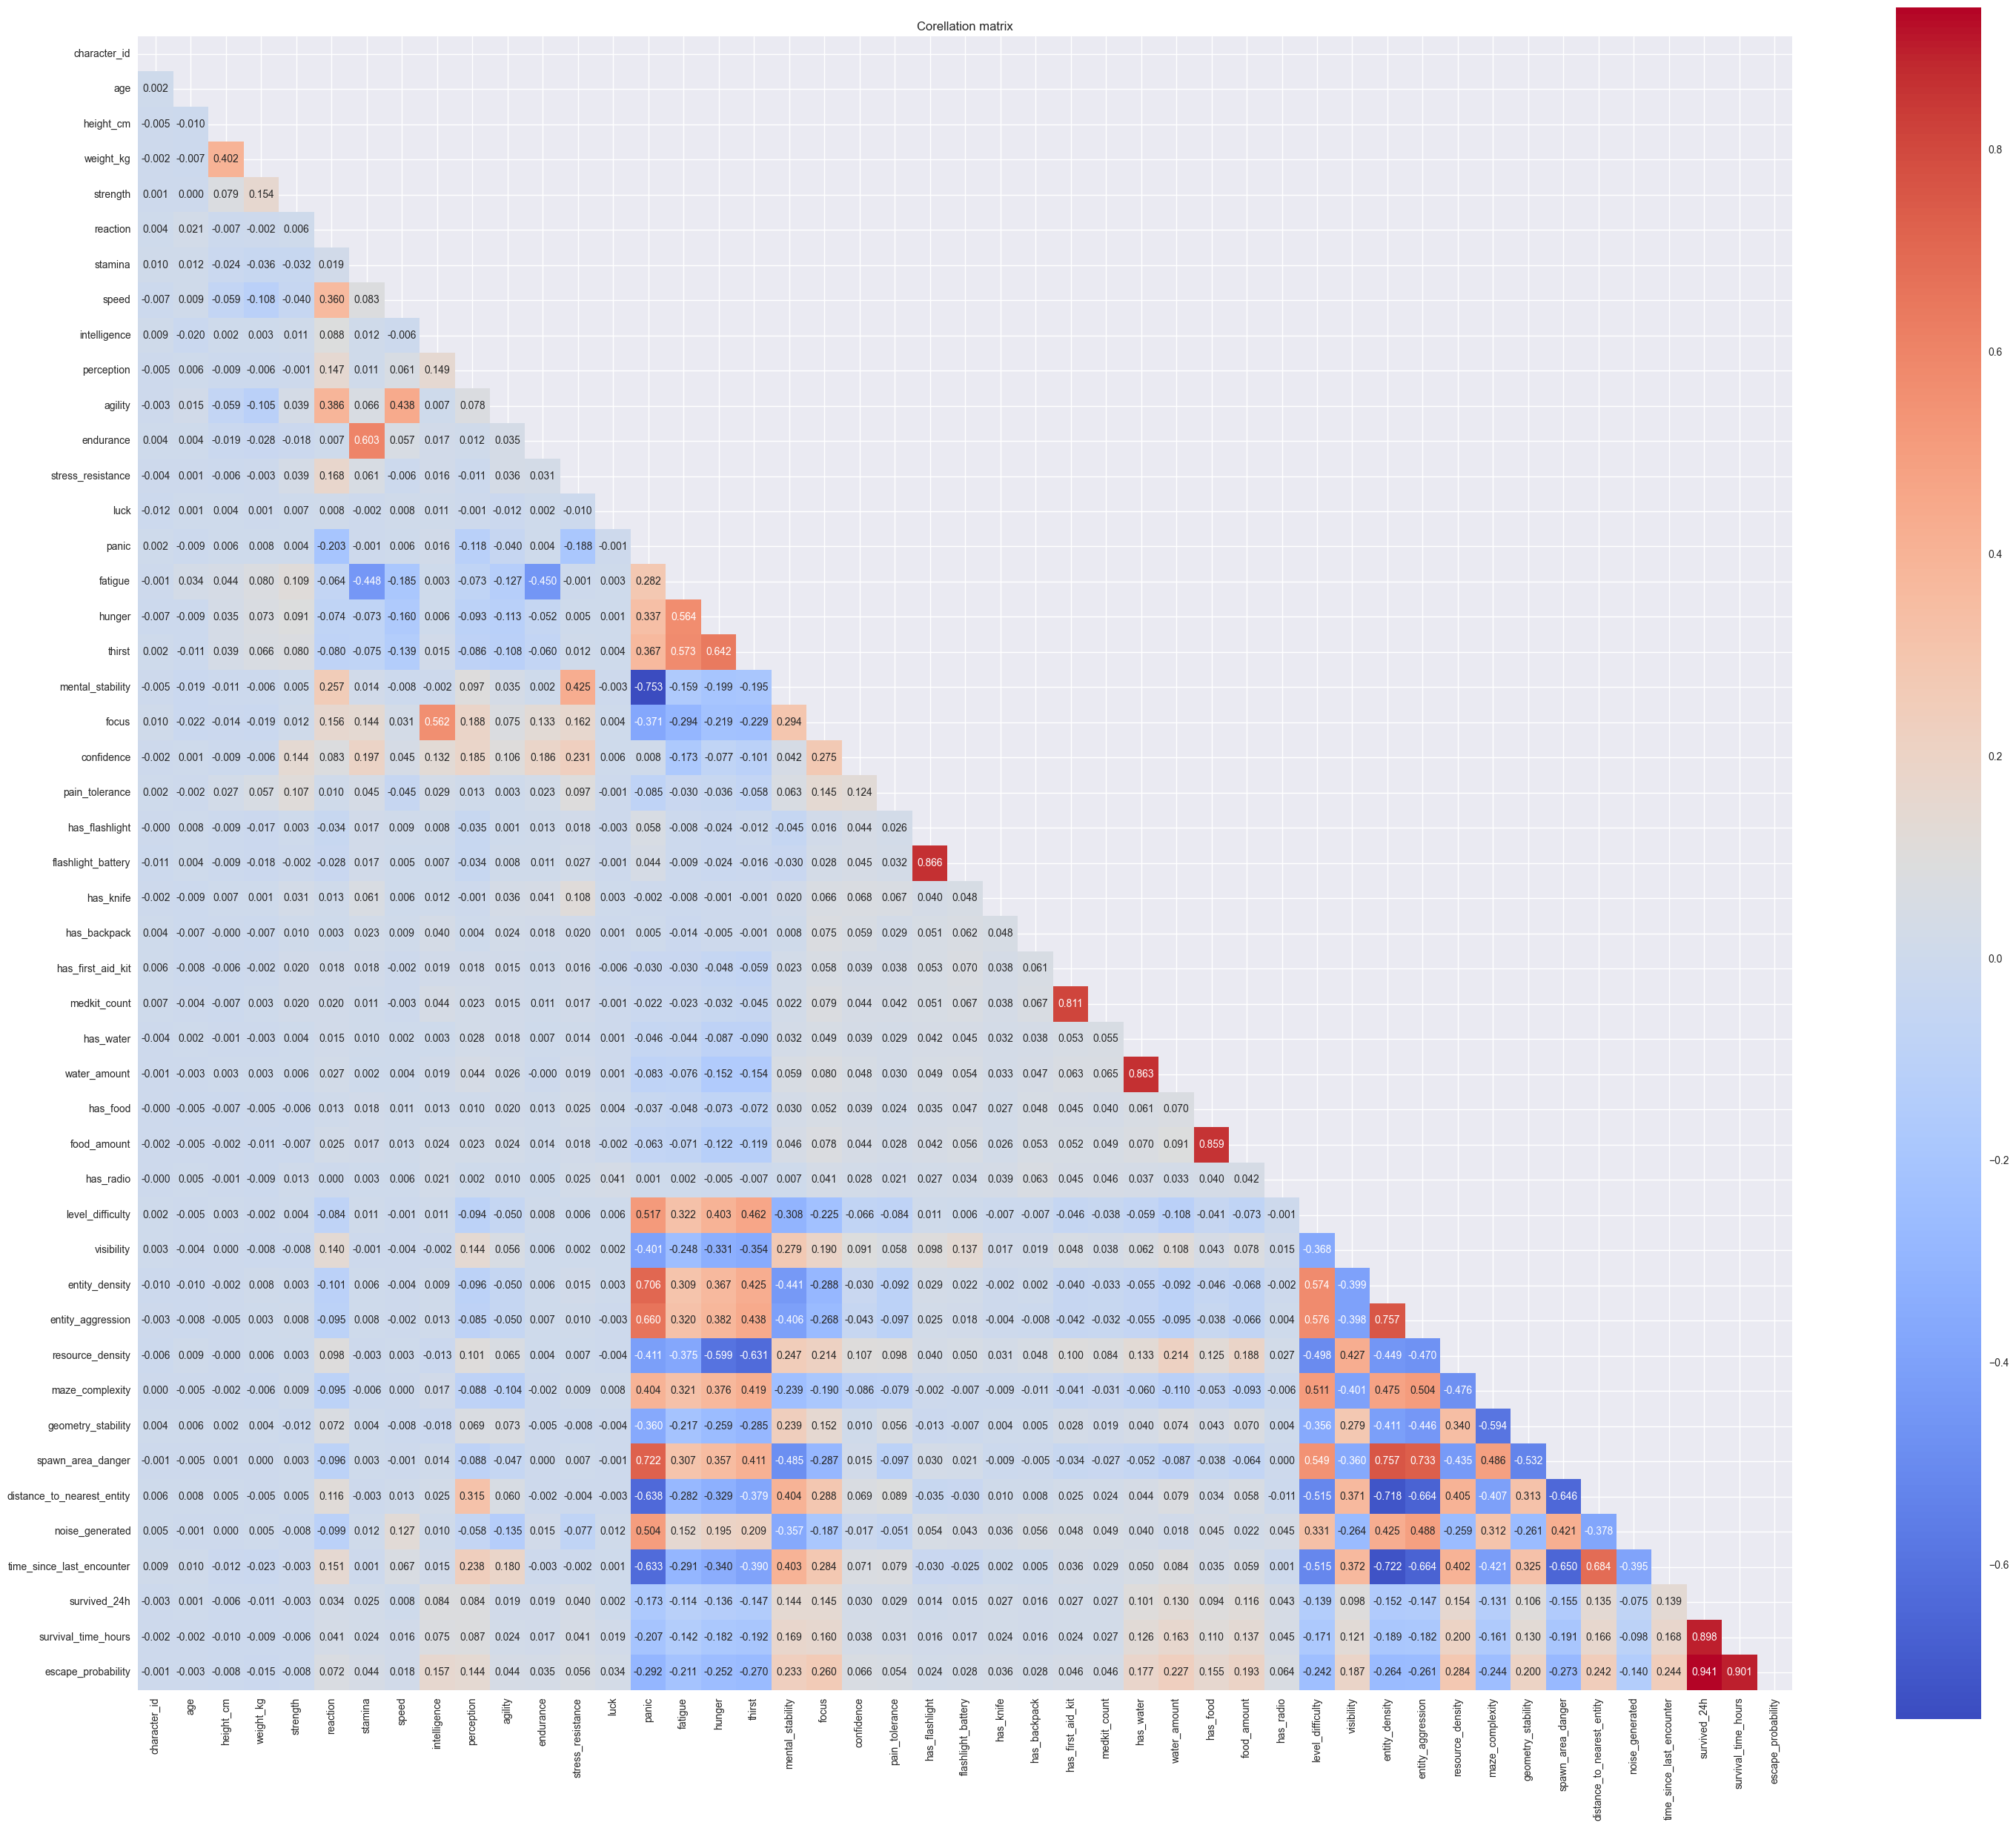

In [13]:
mask = np.triu(np.ones_like(df[numerical].corr(), dtype=bool))

plt.figure(figsize=(36, 30))
sns.heatmap(df[numerical].corr(), mask=mask, cmap='coolwarm', square=True, annot=True, fmt='.3f')
# sns.heatmap(df[numerical].corr(), cmap='coolwarm', fmt='.2f', square=True)
plt.title('Corellation matrix')
plt.show()

# Feature engineering

In [14]:
df = pd.get_dummies(df, columns=['sex', 'level_id', 'special_rule'], drop_first=True)
# df = df.drop(['special_rule_resource_rich'], axis=1)
df = df.replace({True: 1, False: 0})
df.head()

/var/folders/xw/1ypq_4cx13v57g2x9gtl5bz80000gn/T/ipykernel_44275/1493389440.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


,character_id,age,height_cm,weight_kg,strength,reaction,stamina,speed,intelligence,perception,...,level_id_8,level_id_end,special_rule_darkness,special_rule_flooding,special_rule_haunted_hotel,special_rule_liminal_office,special_rule_mechanical_noise,special_rule_neutral,special_rule_resource_rich,special_rule_trap_exit
0,1,37,182,77,4,2,4,4,8,5,...,0,0,0,1,0,0,0,0,0,0
1,2,17,165,61,5,5,6,3,3,5,...,0,0,1,0,0,0,0,0,0,0
2,3,43,169,63,6,5,7,6,6,8,...,0,0,0,0,0,0,0,1,0,0
3,4,31,162,67,5,6,5,5,4,7,...,0,0,0,0,0,0,0,1,0,0
4,5,21,163,60,7,3,4,4,4,3,...,0,0,1,0,0,0,0,0,0,0


In [15]:
# df = df.drop(['spawn_area_danger', 'focus', 'pain_tolerance'], axis=1)
df = df.drop(['character_id'], axis=1)

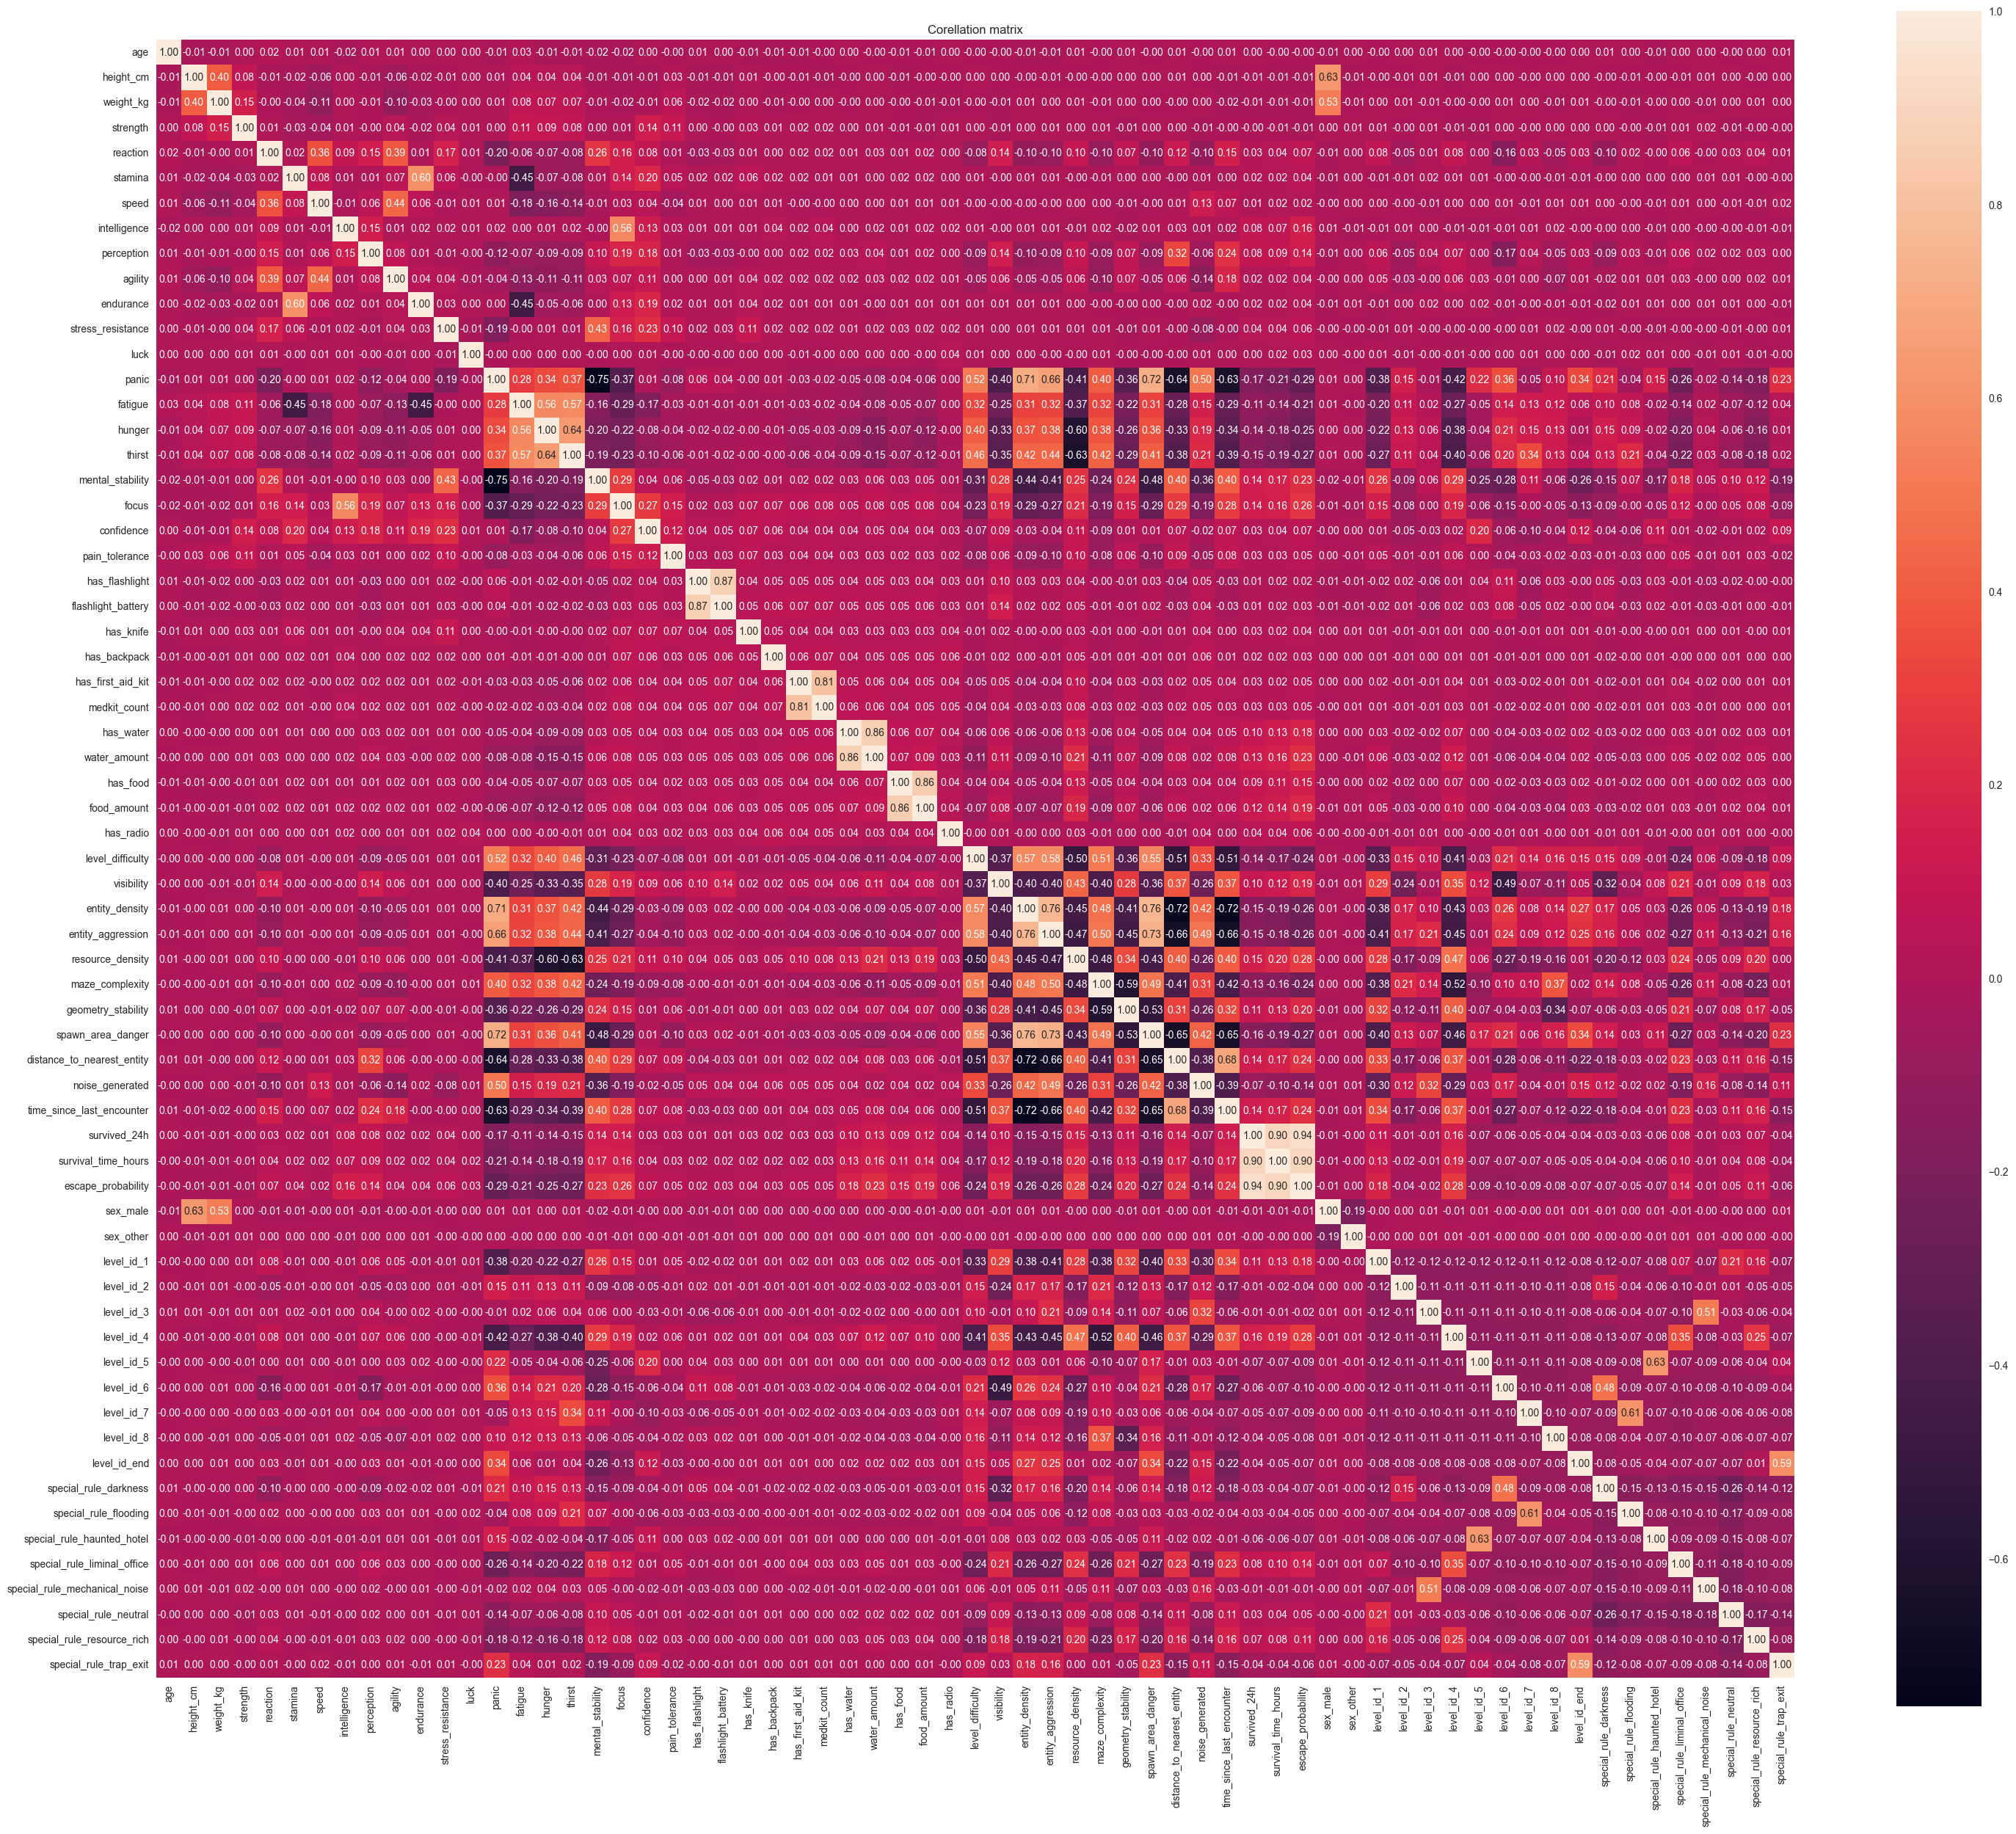

In [16]:
plt.figure(figsize=(36, 30))
sns.heatmap(df.corr(), square=True, annot=True, fmt='.2f')
plt.title('Corellation matrix')
plt.show()

# Saving

In [17]:
df.to_parquet('../data/processed/backrooms_processed.parquet', index=False)
print('parquet-file has been saved into data/processed')

parquet-file has been saved into data/processed
